**класс нетворк:**
* поменять функцию активации и его производную, а также смещение по варианту;
* Реализуем сначала с цифрами и потом с нашими буквами
* Меняем альфа +-0,5 и сранвиваем все три реализации
* выводим графики где берем train как валидационную выборку.
* сравниваем классификэшион репорты

**Фреймворки:**
* пайторч, создаем дропаут, раннюю остановку процентов: 20???
* сравниваем реализацию на функциях остановки лосс: мси и кросс-энтропия
* сравниваем функции оптимизации: сгд и адам
* выводим графики лосс валид
* классификэшион репорт
* сохраняем веса для быстрой загрузки
* Функция окончания: софтмакс
* функциия активация: сигмоида берем по варианту
* слоев и нейронов подбором увеличиваем пока есть улучшения
* керас по желанию

потом пайторч сгд с адамом сранвиваем
добавить классификэшион репорт, добавить графики лосс, валидационная выборка берется из тестовой и потмо по ней делает графики
альфа меняем не только по варианту а плюс минус отклонение 0,5 и посмотреть за что овтечает и сделать три классификэшион репорт чтобы узнать какая из трех реализаций лучше ()
во фреймворках дропаут, ранняя остановка, сравним сгд с адамом, мси и энтропия функции лосса какая лучше (альфа остановимся на одной)
сначала сравниваем мси и кросс-энтропию и уже потом сравниваем сгд с адамом
выводим графики, сохраняем все веса и потом выводим графики
функция окончания софтмакс
пайторч и керас (по желанию)

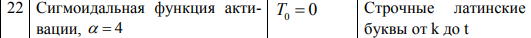

In [1]:
import scipy.io as sio
import numpy as np

mat_data = sio.loadmat('emnist-byclass.mat')

# def process_split(split_name):
#     split_data = mat_data['dataset'][0, 0][split_name][0, 0]
#
#     images = np.array(split_data['images'], dtype=np.uint8)
#     labels = np.array(split_data['labels'], dtype=np.int32).ravel()
#
#     # буквы от k до t
#     mask = (labels >= 46) & (labels <= 55)
#     filtered_images = images[mask]
#     filtered_labels = labels[mask] - 46
#
#     selected_indices = []
#
#     for class_id in range(10):
#         class_indices = np.where(filtered_labels == class_id)[0]
#
#         selected_indices.extend(class_indices[:350])
#
#     selected_indices = np.array(selected_indices)
#
#     filtered_images = filtered_images[selected_indices]
#     filtered_labels = filtered_labels[selected_indices]
#
#     img_2d = filtered_images.reshape(-1, 28, 28)
#     img_corrected = img_2d.transpose(0, 2, 1)
#     final_vectors = img_corrected.reshape(-1, 784)
#
#     return final_vectors, filtered_labels

def process_split(split_name, count = 200):
    split_data = mat_data['dataset'][0, 0][split_name][0, 0]

    images = np.array(split_data['images'], dtype=np.uint8)
    labels = np.array(split_data['labels'], dtype=np.int32).ravel()

    mask = (labels >= 46) & (labels <= 55)
    filtered_images = images[mask]
    numeric_labels = labels[mask] - 46

    selected_indices = []

    for class_id in range(10):
        class_indices = np.where(numeric_labels == class_id)[0]

        selected_indices.extend(class_indices[:count])

    selected_indices = np.array(selected_indices)

    filtered_images = filtered_images[selected_indices]
    numeric_labels = numeric_labels[selected_indices]


    num_classes = 10
    one_hot_labels = np.zeros((numeric_labels.size, num_classes), dtype=np.uint8)
    one_hot_labels[np.arange(numeric_labels.size), numeric_labels] = 1

    img_2d = filtered_images.reshape(-1, 28, 28)
    img_corrected = img_2d.transpose(0, 2, 1)
    final_vectors = img_corrected.reshape(-1, 784)

    return final_vectors, one_hot_labels


X_train, y_train = process_split('train')
X_test, y_test = process_split('test', 100)

np.savez_compressed(
    'emnist_k_to_t_one.npz',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

print(f"Обучающая выборка (train): {X_train.shape[0]} картинок")
print(f"Тестовая выборка (test): {X_test.shape[0]} картинок")



Обучающая выборка (train): 2000 картинок
Тестовая выборка (test): 1000 картинок


In [3]:
import numpy as np

data = np.load('emnist_k_to_t_one.npz')

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

# data = np.load('emnist_k_to_t_one.npz')
#
# y_train_one = data['y_train']
# y_test_one = data['y_test']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Буква 'k' (Класс 0): 350 объектов
Буква 'l' (Класс 1): 350 объектов
Буква 'm' (Класс 2): 350 объектов
Буква 'n' (Класс 3): 350 объектов
Буква 'o' (Класс 4): 350 объектов
Буква 'p' (Класс 5): 350 объектов
Буква 'q' (Класс 6): 350 объектов
Буква 'r' (Класс 7): 350 объектов
Буква 's' (Класс 8): 350 объектов
Буква 't' (Класс 9): 350 объектов
Train: (3500, 784), Test: (3500, 784)


альфа может быть у функции актвивации, делаем, закладываем в классе чтобы менять ее, отвечает за пологость функции
здесь мы можем менять батч в спуске
